Imports & Load Data

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('../data/spotify_tracks.csv')
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (114000, 21)

Data Types:
 Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object


Check Nulls & Duplicates 

In [4]:
print("Null Values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Null Values:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows: 0


Drop Unnecessary Columns

In [5]:
df = df.drop(columns=['Unnamed: 0', 'track_id', 'key', 'mode', 'time_signature', 'explicit'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre']


Feature Distributions

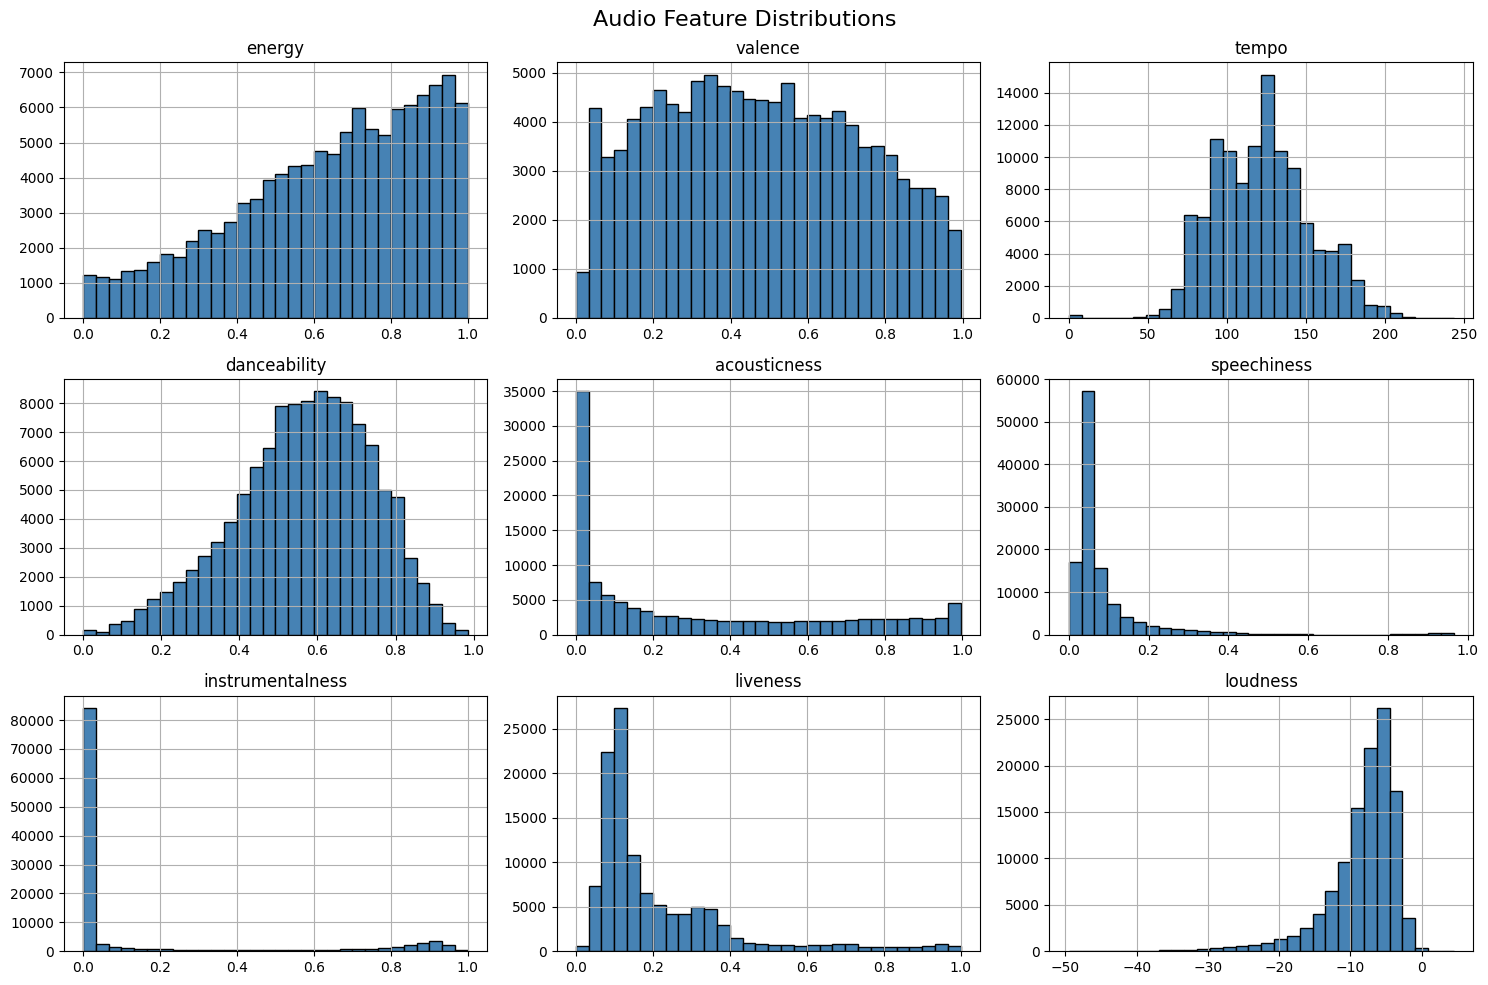

In [6]:
features = ['energy', 'valence', 'tempo', 'danceability', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'loudness']
df[features].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Audio Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

Correlation Heatmap

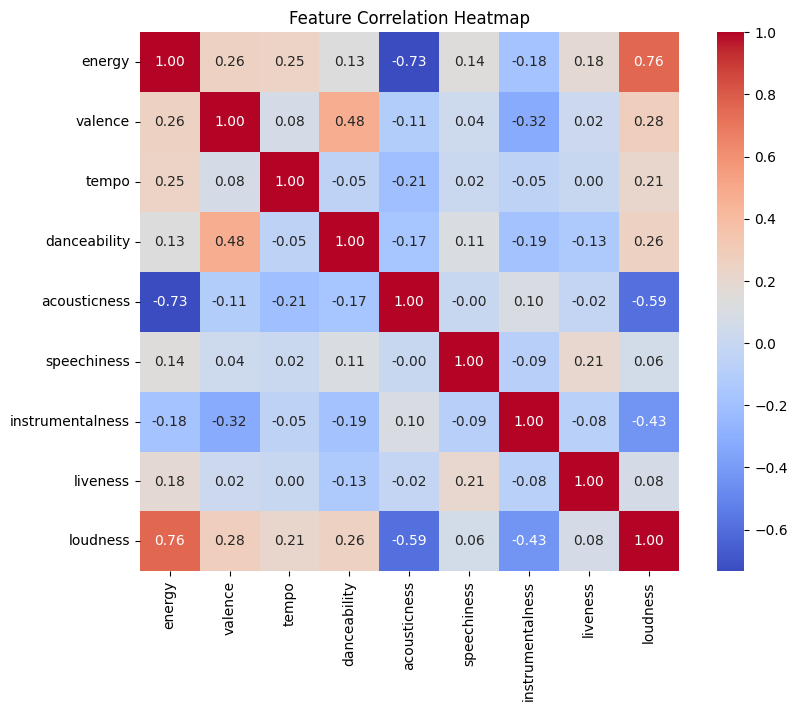

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

Create Mood Labels

In [8]:
def assign_mood(row):
    if row['valence'] > 0.6 and row['energy'] > 0.5:
        return 'Happy'
    elif row['valence'] < 0.4 and row['energy'] < 0.4:
        return 'Sad'
    elif row['tempo'] > 120 and row['energy'] > 0.7:
        return 'Energetic'
    elif row['acousticness'] > 0.6 and row['energy'] < 0.4:
        return 'Calm'
    else:
        return 'Neutral'

df['mood'] = df.apply(assign_mood, axis=1)
print(df['mood'].value_counts())

mood
Neutral      41523
Happy        32867
Energetic    19917
Sad          14510
Calm          5183
Name: count, dtype: int64


Mood Distribution Plot

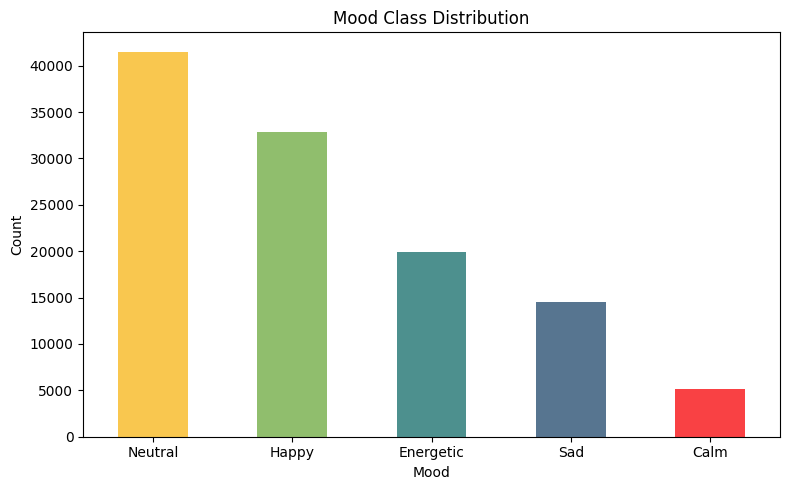

In [9]:
plt.figure(figsize=(8, 5))
df['mood'].value_counts().plot(kind='bar', color=['#f9c74f','#90be6d','#4d908e','#577590','#f94144'])

plt.title('Mood Class Distribution')
plt.xlabel('Mood')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Valence vs Energy Scatter (Visual Proof of Mood Clusters)

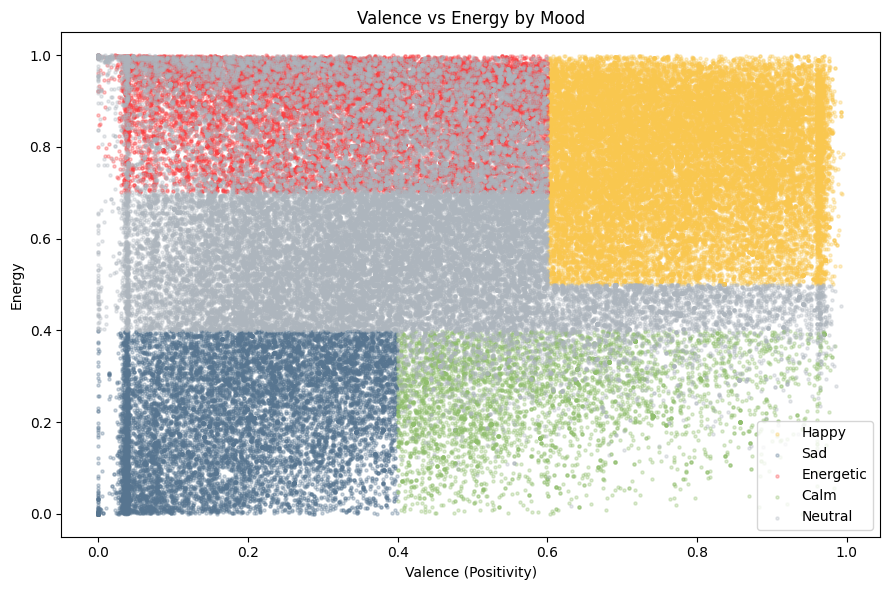

In [10]:
plt.figure(figsize=(9, 6))
colors = {'Happy': '#f9c74f', 'Sad':'#577590', 'Energetic':'#f94144', 'Calm':'#90be6d', 'Neutral':'#adb5bd'}

for mood, color in colors.items():
    subset = df[df['mood'] == mood]
    plt.scatter(subset['valence'], subset['energy'], label=mood, alpha=0.3, s=5, color=color)

plt.xlabel('Valence (Positivity)')
plt.ylabel('Energy')
plt.title('Valence vs Energy by Mood')
plt.legend()
plt.tight_layout()
plt.show()

Preprocessing

Define Features & Target

In [11]:
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity', 'duration_ms']

X = df[feature_cols]
Y = df['mood']

print("X shape: ", X.shape)
print("Y shape: ", Y.shape)

X shape:  (114000, 11)
Y shape:  (114000,)


Handle Missing Values

In [12]:
print("Missing values in X:\n", X.isnull().sum())
X = X.fillna(X.median())
print("\nAfter fill - Missing values:", X.isnull().sum().sum())

Missing values in X:
 danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
popularity          0
duration_ms         0
dtype: int64

After fill - Missing values: 0


Scale Features

In [13]:
# SVM is sensitive to scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean (Should be ~0): ", X_scaled.mean(axis=0).round(2))
print("Std (Should be ~1): ", X_scaled.std(axis=0).round(2))

Mean (Should be ~0):  [ 0. -0. -0.  0. -0. -0.  0.  0. -0. -0.  0.]
Std (Should be ~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Apply PCA - Princpal Component Analysis

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95) #Keep componenets explaining 95% of variance
X_pca = pca.fit_transform(X_scaled)

print("Original features: ", X_scaled.shape[1])
print("After PCA features: ", X_pca.shape[1])
print("Variance Explained: ", pca.explained_variance_ratio_.cumsum().round(3))

Original features:  11
After PCA features:  9
Variance Explained:  [0.261 0.4   0.513 0.608 0.695 0.774 0.85  0.916 0.958]


Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_pca, Y, test_size=0.2, random_state=42, stratify=Y
)

print('Train size: ', X_train.shape)
print('Test size: ', X_test.shape)
print('\nClass distribution in train:\n', Y_train.value_counts())

Train size:  (91200, 9)
Test size:  (22800, 9)

Class distribution in train:
 mood
Neutral      33218
Happy        26294
Energetic    15934
Sad          11608
Calm          4146
Name: count, dtype: int64


Model Training

Train Naive Bayes(Baseline)

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)
nb_pred = nb_model.predict(X_test)

print("===Naive Bayes===")
print("Accuracy: ", round(accuracy_score(Y_test, nb_pred), 4))
print(classification_report(Y_test, nb_pred))

===Naive Bayes===
Accuracy:  0.784
              precision    recall  f1-score   support

        Calm       0.69      0.66      0.67      1037
   Energetic       0.77      0.71      0.73      3983
       Happy       0.82      0.88      0.85      6573
     Neutral       0.76      0.76      0.76      8305
         Sad       0.82      0.79      0.81      2902

    accuracy                           0.78     22800
   macro avg       0.77      0.76      0.76     22800
weighted avg       0.78      0.78      0.78     22800



Train SVM(Main Model)

In [17]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, Y_train)

svm_pred = svm_model.predict(X_test)

print("=== SVM ===")
print("Accuracy:", round(accuracy_score(Y_test, svm_pred), 4))
print(classification_report(Y_test, svm_pred))

=== SVM ===
Accuracy: 0.9095
              precision    recall  f1-score   support

        Calm       0.87      0.82      0.84      1037
   Energetic       0.91      0.91      0.91      3983
       Happy       0.94      0.96      0.95      6573
     Neutral       0.88      0.89      0.89      8305
         Sad       0.92      0.89      0.90      2902

    accuracy                           0.91     22800
   macro avg       0.91      0.89      0.90     22800
weighted avg       0.91      0.91      0.91     22800



Train ANN(Bonus Model)

In [18]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=300, random_state=42)
ann_model.fit(X_train, Y_train)

ann_pred = ann_model.predict(X_test)
print('=== ANN ===')
print('Accuracy: ', round(accuracy_score(Y_test, ann_pred), 4))
print(classification_report(Y_test, ann_pred))

=== ANN ===
Accuracy:  0.9341
              precision    recall  f1-score   support

        Calm       0.89      0.88      0.88      1037
   Energetic       0.95      0.93      0.94      3983
       Happy       0.96      0.97      0.96      6573
     Neutral       0.91      0.92      0.92      8305
         Sad       0.94      0.91      0.93      2902

    accuracy                           0.93     22800
   macro avg       0.93      0.92      0.93     22800
weighted avg       0.93      0.93      0.93     22800



Model Comparision Table

In [19]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM', 'ANN'],
    'Accuracy': [
        accuracy_score(Y_test, nb_pred),
        accuracy_score(Y_test, svm_pred),
        accuracy_score(Y_test, ann_pred)
    ]
})

results['Accuracy'] = results['Accuracy'].round(4)
print(results.to_string(index=False))

      Model  Accuracy
Naive Bayes    0.7840
        SVM    0.9095
        ANN    0.9341


Confusion matrix for best Model

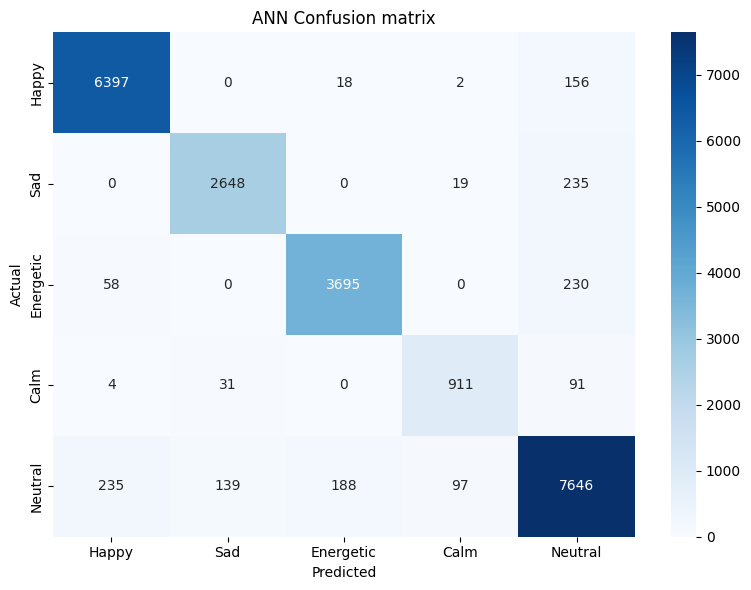

In [20]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(Y_test, ann_pred,
                      labels=['Happy', 'Sad', 'Energetic', 'Calm', 'Neutral'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Happy', 'Sad', 'Energetic', 'Calm', 'Neutral'],
            yticklabels=['Happy', 'Sad', 'Energetic', 'Calm', 'Neutral'])

plt.title('ANN Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Save all Models

In [21]:
import joblib

joblib.dump(ann_model, '../backend/mood_model.pkl')
joblib.dump(scaler, '../backend/scaler.pkl')
joblib.dump(pca, '../backend/pca.pkl')

print('All Model saved to backend/')

All Model saved to backend/


K-Means Clustering


In [22]:
from sklearn.cluster import KMeans

KMeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = KMeans.fit_predict(X_scaled)

print("Cluster distribution:\n", df['cluster'].value_counts())

Cluster distribution:
 cluster
1    41320
2    31303
0    24725
3     8403
4     8249
Name: count, dtype: int64


Map Clusters to Moods

In [23]:
cluster_mood_map = df.groupby('cluster')['mood'].agg(
    lambda x: x.value_counts().index[0]
)
print('Cluster -> Mood mapping: \n', cluster_mood_map)

Cluster -> Mood mapping: 
 cluster
0      Neutral
1        Happy
2    Energetic
3      Neutral
4          Sad
Name: mood, dtype: str


Visulize Clusters with PCA

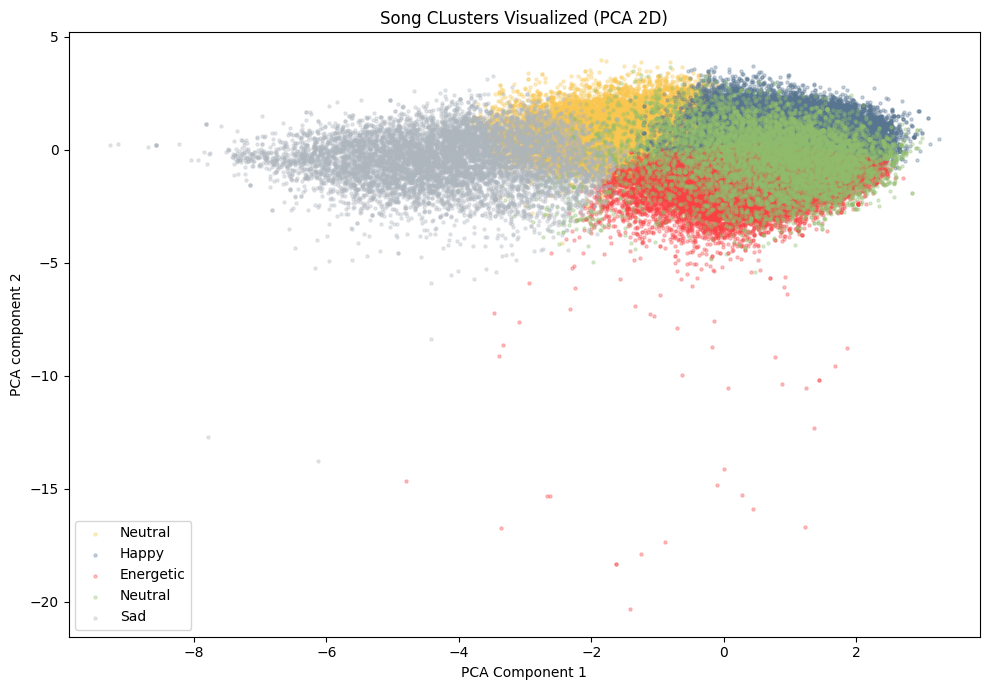

In [24]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['#f9c74f', '#577590', '#f94144', '#90be6d', '#adb5bd']

for i in range(5):
    mask = df['cluster'] == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[i], label=cluster_mood_map[i],
                alpha=0.3, s=5)
    
plt.title('Song CLusters Visualized (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA component 2')
plt.legend()
plt.tight_layout()
plt.show()

Build Playlist Data & Save as JSON


In [25]:
playlist = {}
for mood in ['Happy', 'Sad', 'Energetic', 'Calm', 'Neutral']:
    matched = cluster_mood_map[cluster_mood_map == mood].index
    if len(matched) == 0:
        print(f"Skipping missing mood mapping: {mood}")
        continue
    cluster_id = matched[0]

    songs = df[df['cluster'] == cluster_id][['track_name', 'artists', 'popularity', 'mood']]
    songs = songs.sort_values('popularity', ascending=False).head(20)
    playlist[mood] = songs.to_dict(orient='records')
    print(f"{mood}: {len(playlist[mood])} songs")

Happy: 20 songs
Sad: 20 songs
Energetic: 20 songs
Skipping missing mood mapping: Calm
Neutral: 20 songs


Fix Missing Moods with Fallback

In [28]:
import json
missing_moods = ['Happy', 'Sad', 'Energetic', 'Calm', 'Neutral']

for mood in missing_moods:
    if mood not in playlist:
        print(f'Building fallback playlist for: {mood}')
        songs = df[df['mood'] == mood][['track_name', 'artists', 'popularity', 'mood']]
        songs = songs.drop_duplicates(subset=['track_name', 'artists'])
        songs = songs.sort_values('popularity', ascending=False).head(50)
        playlist[mood] = songs.to_dict(orient='records')
        print(f"  -> Added {len(playlist[mood])} songs")

for mood in ['Happy', 'Sad', 'Energetic', 'Neutral']:
    if mood in playlist:
        seen = set()
        unique_songs = []
        for song in playlist[mood]:
            key = (song['track_name'], song['artists'])
            if key not in seen:
                seen.add(key)
                unique_songs.append(song)
        playlist[mood] = unique_songs[:20]

with open('../backend/playlist_data.json', 'w') as f:
    json.dump(playlist, f, indent=2)

print("\nFinal playlist saved wiht all 5 moods:")
for mood, songs in playlist.items():
    print(f"  {mood}: {len(songs)} songs")


Final playlist saved wiht all 5 moods:
  Happy: 8 songs
  Sad: 13 songs
  Energetic: 11 songs
  Neutral: 8 songs
  Calm: 20 songs


Save KMeans Model

In [29]:
joblib.dump(KMeans, '../backend/kmeans.pkl')
print('kmeans model saved')

kmeans model saved
